# Phase 1: Behavioral Sweep — PI > RI in Transformers

Full interference landscape mapping.

**Pruned grid (based on 0.5B + 1.5B results):**
- Keys: [2, 3, 5, 7, 10, 15, 20, 25, 30, 46] (10 levels — dropped 35, 40)
- Updates: [1, 3, 5, 10, 20, 50, 100, 200] (8 levels — pattern is clear, no need for fine resolution)
- ~80 cells × 100 trials × 2 conditions = 16,000 trials

**Models swept:**
- [x] Qwen2.5-0.5B-Instruct (DONE — 135 cells, 30 trials)
- [x] Qwen2.5-1.5B-Instruct (DONE — 243 cells, 30 trials)
- [x] Qwen2.5-3B-Instruct (DONE — 75 cells, 100 trials)
- [ ] Gemma-3-1B-IT (TODO — pruned grid, 100 trials)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Install dependencies (Colab only — skip locally)
!pip install -q transformers accelerate scipy
!pip install -q sympy --upgrade  # Fix sympy.printing AttributeError on Colab

# HuggingFace auth — needed for gated models (Gemma, Llama, etc.)
import os

In [ ]:
HF_TOKEN = "REDACTED_HF_TOKEN"
# ═══════════════════════════════════════════════════════════════════════════
# EXPERIMENT CONFIG — All settings in one place
# Change these before running. Everything else reads from this dict.
# ═══════════════════════════════════════════════════════════════════════════

EXPERIMENT_CONFIG = {
    # ── Model ──
    "model_name": "google/gemma-3-1b-it",
    # Previous runs:
    # "model_name": "Qwen/Qwen2.5-0.5B-Instruct",  # DONE (135 cells, 30 trials)
    # "model_name": "Qwen/Qwen2.5-1.5B-Instruct",  # DONE (243 cells, 30 trials)
    # "model_name": "Qwen/Qwen2.5-3B-Instruct",     # DONE (75 cells, 100 trials)

    # ── Grid ──
    "key_levels": [2, 3, 5, 7, 10, 15, 20, 25, 30, 46],
    "update_levels": [1, 3, 5, 10, 20, 50, 100, 200],
    # Full grid (uncomment for exhaustive sweep):
    # "key_levels": [2, 3, 5, 7, 10, 15, 20, 25, 30, 35, 40, 46],
    # "update_levels": [1, 3, 5, 10, 15, 20, 30, 40, 50, 60, 80, 100, 120, 140, 160, 180, 200],

    # ── Trials ──
    "trials_per_cell": 100,

    # ── Data ──
    "num_categories": 46,
    "value_type": "synthetic",        # "synthetic" (Art375) or "single_token" (English words)
    "system_prompt": "Answer with ONLY the exact value. No explanation.",

    # ── Paths ──
    "save_dir": "/content/results",
    "save_dir_drive": "/content/drive/MyDrive/mechanistic_probing_results",
    "figures_dir": "/content/figures",

    # ── Early stopping ──
    "ri_zero_threshold": 2,           # Stop row after N consecutive 0% RI cells
    "pi_zero_threshold": 1,           # Stop row after N consecutive 0% PI cells

    # ── Metadata ──
    "experiment_type": "behavioral_sweep",
    "date": None,  # Set at runtime
}

# Convenience aliases used by the rest of the notebook
MODEL_NAME = EXPERIMENT_CONFIG["model_name"]
TRIALS_PER_CELL = EXPERIMENT_CONFIG["trials_per_cell"]

print(f"Config loaded:")
print(f"  Model:  {EXPERIMENT_CONFIG['model_name']}")
print(f"  Grid:   {len(EXPERIMENT_CONFIG['key_levels'])} keys × {len(EXPERIMENT_CONFIG['update_levels'])} updates")
print(f"  Trials: {EXPERIMENT_CONFIG['trials_per_cell']} per cell")
print(f"  Values: {EXPERIMENT_CONFIG['value_type']}")

In [ ]:
import os
from pathlib import Path

from google.colab import drive
drive.mount('/content/drive')

# Read paths from EXPERIMENT_CONFIG
SAVE_DIR = EXPERIMENT_CONFIG["save_dir"]
FIGURES_DIR = EXPERIMENT_CONFIG["figures_dir"]
SAVE_DIR_DRIVE = EXPERIMENT_CONFIG["save_dir_drive"]

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(SAVE_DIR_DRIVE, exist_ok=True)

print(f'Results: {SAVE_DIR}')
print(f'Drive backup: {SAVE_DIR_DRIVE}')
print(f'Figures: {FIGURES_DIR}')
print(f'Existing results: {os.listdir(SAVE_DIR)}')

In [4]:
import torch
import json
import time
import random
import numpy as np
from pathlib import Path
from transformers import AutoModelForCausalLM, AutoTokenizer

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name()}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


## Dataset Generation Module

In [5]:
# # ═══════════════════════════════════════════════════════════════════════════
# # Dataset generation — self-contained, no external imports
# # ═══════════════════════════════════════════════════════════════════════════

# ORIGINAL_CATEGORIES = [
#     "visual art", "tools", "landform", "musical instrument", "gemstone",
#     "fabric", "tree species", "cheese variety", "architectural style",
#     "cloud formation", "bird species", "culinary herb", "flower species",
#     "wine variety", "dance style", "pasta shape", "literary genre",
#     "cooking method", "mathematical concept", "weather phenomenon",
#     "ocean current", "mineral type", "coffee variety", "telescope type",
#     "martial art", "sea creature", "psychology term", "chemical element",
#     "dinosaur genus", "programming language", "ancient civilization",
#     "bridge type", "photography technique", "boat type", "cartoon character",
#     "stadium name", "surgical procedure", "constellation", "spice blend",
#     "guitar type", "hat style", "painting medium", "volcano name",
#     "fruit variety", "sword type", "board game",
# ]

# PREFIX_MAP = {
#     "visual art": "Art", "tools": "Tool", "landform": "Land",
#     "musical instrument": "Inst", "gemstone": "Gem", "fabric": "Fab",
#     "tree species": "Tree", "cheese variety": "Cheese",
#     "architectural style": "Style", "cloud formation": "Cloud",
#     "bird species": "Bird", "culinary herb": "Herb",
#     "flower species": "Flower", "wine variety": "Wine",
#     "dance style": "Dance", "pasta shape": "Pasta",
#     "literary genre": "Genre", "cooking method": "Cook",
#     "mathematical concept": "Math", "weather phenomenon": "Weather",
#     "ocean current": "Current", "mineral type": "Mineral",
#     "coffee variety": "Coffee", "telescope type": "Scope",
#     "martial art": "Martial", "sea creature": "Sea",
#     "psychology term": "Psych", "chemical element": "Elem",
#     "dinosaur genus": "Dino", "programming language": "Lang",
#     "ancient civilization": "Civ", "bridge type": "Bridge",
#     "photography technique": "Photo", "boat type": "Boat",
#     "cartoon character": "Toon", "stadium name": "Stadium",
#     "surgical procedure": "Surg", "constellation": "Star",
#     "spice blend": "Spice", "guitar type": "Guitar",
#     "hat style": "Hat", "painting medium": "Medium",
#     "volcano name": "Volcano", "fruit variety": "Fruit",
#     "sword type": "Sword", "board game": "Game",
# }

# KEY_LEVELS = [2, 3, 5, 7, 10, 15, 20, 25, 30, 35, 40, 46]
# # Capped at 200 — pattern is clear by then, higher just wastes GPU time
# UPDATE_LEVELS = [
#     1, 3, 5, 10, 15, 20,
#     30, 40, 50, 60,
#     80, 100, 120, 140, 160, 180, 200,
#     220, 240, 260, 280, 300, 320, 340, 
#     360, 380, 400, 420, 440, 460, 480, 500
# ]

# SYSTEM_PROMPT = "Answer with ONLY the exact value. No explanation."


# def generate_value_pool(category, pool_size=500):
#     prefix = PREFIX_MAP.get(category, category.split()[0].capitalize())
#     return [f"{prefix}{i}" for i in range(1, pool_size + 1)]


# def shuffle_no_consecutive(items, rng, max_attempts=100):
#     """Shuffle ensuring no consecutive same-category items."""
#     for _ in range(max_attempts):
#         candidate = items.copy()
#         rng.shuffle(candidate)
#         ok = True
#         for i in range(1, len(candidate)):
#             if candidate[i]["category"] == candidate[i-1]["category"]:
#                 ok = False
#                 break
#         if ok:
#             return candidate
#     # Fallback: greedy
#     remaining = items.copy()
#     rng.shuffle(remaining)
#     result = []
#     last_cat = None
#     while remaining:
#         valid = [i for i, item in enumerate(remaining) if item["category"] != last_cat]
#         if not valid:
#             result.extend(remaining)
#             break
#         idx = rng.choice(valid)
#         item = remaining.pop(idx)
#         result.append(item)
#         last_cat = item["category"]
#     return result


# def generate_trial(num_keys, num_updates, condition, seed, test_category_idx=0):
#     rng = random.Random(seed)
#     categories = rng.sample(ORIGINAL_CATEGORIES, min(num_keys, len(ORIGINAL_CATEGORIES)))
    
#     values_per_cat = {}
#     for cat in categories:
#         pool = generate_value_pool(cat, pool_size=max(num_updates + 50, 500))
#         selected = rng.sample(pool, num_updates)
#         values_per_cat[cat] = selected
    
#     test_category = categories[test_category_idx % len(categories)]
    
#     # Build interleaved sequence
#     items = []
#     for cat in categories:
#         for idx, val in enumerate(values_per_cat[cat]):
#             items.append({"category": cat, "value": val, "update_idx": idx})
#     sequence = shuffle_no_consecutive(items, rng)
    
#     # Build prompt
#     stream_lines = [f"{item['category']}: {item['value']}" for item in sequence]
#     stream_text = "\n".join(stream_lines)
#     query_word = "first" if condition == "RI" else "last"
#     cat_values = [item["value"] for item in sequence if item["category"] == test_category]
#     expected = cat_values[0] if condition == "RI" else cat_values[-1]
    
#     prompt = (
#         f"Read the following key-value stream. Each key gets updated multiple times.\n\n"
#         f"{stream_text}\n\n"
#         f"What was the {query_word} value of {test_category}?"
#     )
    
#     return {
#         "prompt": prompt,
#         "expected": expected,
#         "condition": condition,
#         "test_category": test_category,
#         "initial_value": cat_values[0],
#         "final_value": cat_values[-1],
#         "all_values": cat_values,
#         "num_keys": num_keys,
#         "num_updates": num_updates,
#         "seed": seed,
#     }


# def format_for_chat(prompt, tokenizer):
#     if hasattr(tokenizer, "apply_chat_template"):
#         messages = [
#             {"role": "system", "content": SYSTEM_PROMPT},
#             {"role": "user", "content": prompt},
#         ]
#         return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
#     return prompt


# print(f"Categories: {len(ORIGINAL_CATEGORIES)}")
# print(f"Grid: {len(KEY_LEVELS)} key levels x {len(UPDATE_LEVELS)} update levels = {len(KEY_LEVELS)*len(UPDATE_LEVELS)} cells")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Dataset generation — self-contained, no external imports
# All grid/prompt settings read from EXPERIMENT_CONFIG (cell 2)
# ═══════════════════════════════════════════════════════════════════════════

ORIGINAL_CATEGORIES = [
    "visual art", "tools", "landform", "musical instrument", "gemstone",
    "fabric", "tree species", "cheese variety", "architectural style",
    "cloud formation", "bird species", "culinary herb", "flower species",
    "wine variety", "dance style", "pasta shape", "literary genre",
    "cooking method", "mathematical concept", "weather phenomenon",
    "ocean current", "mineral type", "coffee variety", "telescope type",
    "martial art", "sea creature", "psychology term", "chemical element",
    "dinosaur genus", "programming language", "ancient civilization",
    "bridge type", "photography technique", "boat type", "cartoon character",
    "stadium name", "surgical procedure", "constellation", "spice blend",
    "guitar type", "hat style", "painting medium", "volcano name",
    "fruit variety", "sword type", "board game",
]

PREFIX_MAP = {
    "visual art": "Art", "tools": "Tool", "landform": "Land",
    "musical instrument": "Inst", "gemstone": "Gem", "fabric": "Fab",
    "tree species": "Tree", "cheese variety": "Cheese",
    "architectural style": "Style", "cloud formation": "Cloud",
    "bird species": "Bird", "culinary herb": "Herb",
    "flower species": "Flower", "wine variety": "Wine",
    "dance style": "Dance", "pasta shape": "Pasta",
    "literary genre": "Genre", "cooking method": "Cook",
    "mathematical concept": "Math", "weather phenomenon": "Weather",
    "ocean current": "Current", "mineral type": "Mineral",
    "coffee variety": "Coffee", "telescope type": "Scope",
    "martial art": "Martial", "sea creature": "Sea",
    "psychology term": "Psych", "chemical element": "Elem",
    "dinosaur genus": "Dino", "programming language": "Lang",
    "ancient civilization": "Civ", "bridge type": "Bridge",
    "photography technique": "Photo", "boat type": "Boat",
    "cartoon character": "Toon", "stadium name": "Stadium",
    "surgical procedure": "Surg", "constellation": "Star",
    "spice blend": "Spice", "guitar type": "Guitar",
    "hat style": "Hat", "painting medium": "Medium",
    "volcano name": "Volcano", "fruit variety": "Fruit",
    "sword type": "Sword", "board game": "Game",
}

# ── Read grid from EXPERIMENT_CONFIG ──
KEY_LEVELS = EXPERIMENT_CONFIG["key_levels"]
UPDATE_LEVELS = EXPERIMENT_CONFIG["update_levels"]
SYSTEM_PROMPT = EXPERIMENT_CONFIG["system_prompt"]


def generate_value_pool(category, pool_size=500):
    prefix = PREFIX_MAP.get(category, category.split()[0].capitalize())
    return [f"{prefix}{i}" for i in range(1, pool_size + 1)]


def shuffle_no_consecutive(items, rng, max_attempts=100):
    """Shuffle ensuring no consecutive same-category items."""
    for _ in range(max_attempts):
        candidate = items.copy()
        rng.shuffle(candidate)
        ok = True
        for i in range(1, len(candidate)):
            if candidate[i]["category"] == candidate[i-1]["category"]:
                ok = False
                break
        if ok:
            return candidate
    # Fallback: greedy
    remaining = items.copy()
    rng.shuffle(remaining)
    result = []
    last_cat = None
    while remaining:
        valid = [i for i, item in enumerate(remaining) if item["category"] != last_cat]
        if not valid:
            result.extend(remaining)
            break
        idx = rng.choice(valid)
        item = remaining.pop(idx)
        result.append(item)
        last_cat = item["category"]
    return result


def generate_trial(num_keys, num_updates, condition, seed, test_category_idx=0):
    rng = random.Random(seed)
    categories = rng.sample(ORIGINAL_CATEGORIES, min(num_keys, len(ORIGINAL_CATEGORIES)))
    
    values_per_cat = {}
    for cat in categories:
        pool = generate_value_pool(cat, pool_size=max(num_updates + 50, 500))
        selected = rng.sample(pool, num_updates)
        values_per_cat[cat] = selected
    
    test_category = categories[test_category_idx % len(categories)]
    
    # Build interleaved sequence
    items = []
    for cat in categories:
        for idx, val in enumerate(values_per_cat[cat]):
            items.append({"category": cat, "value": val, "update_idx": idx})
    sequence = shuffle_no_consecutive(items, rng)
    
    # Build prompt
    stream_lines = [f"{item['category']}: {item['value']}" for item in sequence]
    stream_text = "\n".join(stream_lines)
    query_word = "first" if condition == "RI" else "last"
    cat_values = [item["value"] for item in sequence if item["category"] == test_category]
    expected = cat_values[0] if condition == "RI" else cat_values[-1]
    
    prompt = (
        f"Read the following key-value stream. Each key gets updated multiple times.\n\n"
        f"{stream_text}\n\n"
        f"What was the {query_word} value of {test_category}?"
    )
    
    return {
        "prompt": prompt,
        "expected": expected,
        "condition": condition,
        "test_category": test_category,
        "initial_value": cat_values[0],
        "final_value": cat_values[-1],
        "all_values": cat_values,
        "num_keys": num_keys,
        "num_updates": num_updates,
        "seed": seed,
    }


def format_for_chat(prompt, tokenizer):
    if hasattr(tokenizer, "apply_chat_template"):
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": prompt},
        ]
        return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    return prompt


print(f"Categories: {len(ORIGINAL_CATEGORIES)}")
print(f"Grid: {len(KEY_LEVELS)} key levels x {len(UPDATE_LEVELS)} update levels = {len(KEY_LEVELS)*len(UPDATE_LEVELS)} cells")
print(f"Estimated trials: {len(KEY_LEVELS)*len(UPDATE_LEVELS) * TRIALS_PER_CELL * 2:,}")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Model loading — reads MODEL_NAME from EXPERIMENT_CONFIG (cell 2)
# ═══════════════════════════════════════════════════════════════════════════

hf_token = os.environ.get("HF_TOKEN", None)

print(f"Loading {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, token=hf_token)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=torch.float16, device_map=DEVICE, token=hf_token,
)
model.eval()
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Left-padding required for batched generation with decoder-only models
tokenizer.padding_side = "left"

n_params = sum(p.numel() for p in model.parameters())
ctx_limit = model.config.max_position_embeddings
print(f"Loaded: {n_params:,} params, ctx={ctx_limit}")

# torch.compile — free 10-30% speedup on T4
if DEVICE == 'cuda':
    try:
        model = torch.compile(model, mode="reduce-overhead")
        # Warm up with a dummy forward pass to trigger compilation
        dummy = tokenizer("Hello", return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            model.generate(**dummy, max_new_tokens=1)
        del dummy
        torch.cuda.empty_cache()
        print("torch.compile: enabled (reduce-overhead mode)")
    except Exception as e:
        print(f"torch.compile: skipped ({e})")

# Memory budget for batch sizing
if DEVICE == 'cuda':
    gpu_mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    model_mem_gb = n_params * 2 / 1e9  # fp16 = 2 bytes per param
    free_for_kv = gpu_mem_gb - model_mem_gb - 1.0  # 1GB safety margin
    print(f"GPU: {gpu_mem_gb:.1f} GB total, ~{model_mem_gb:.1f} GB model, ~{free_for_kv:.1f} GB for KV cache")
else:
    free_for_kv = 4.0  # conservative fallback

In [9]:
def preflight_context_check(num_keys, num_updates, tokenizer, context_limit, safety_margin=0.90):
    trial = generate_trial(num_keys, num_updates, "RI", seed=0)
    formatted = format_for_chat(trial["prompt"], tokenizer)
    tokens = tokenizer.encode(formatted)
    n_tokens = len(tokens)
    limit = int(context_limit * safety_margin)
    return n_tokens <= limit, n_tokens


# Compute feasible grid
feasible = {}
for nk in KEY_LEVELS:
    for nu in UPDATE_LEVELS:
        ok, n_tokens = preflight_context_check(nk, nu, tokenizer, ctx_limit)
        if ok:
            feasible[(nk, nu)] = n_tokens
        else:
            break  # higher updates won't fit either

print(f"Feasible cells: {len(feasible)} / {len(KEY_LEVELS) * len(UPDATE_LEVELS)}")
print(f"\n{'Keys':>6} | Max updates | Est. tokens")
print(f"{'-'*6}-+-{'-'*11}-+-{'-'*11}")
for nk in KEY_LEVELS:
    max_nu = max((nu for (k, nu) in feasible if k == nk), default=0)
    if max_nu > 0:
        est = feasible[(nk, max_nu)]
        print(f"{nk:>6} | {max_nu:>11} | {est:>11,}")
    else:
        print(f"{nk:>6} | {'NONE':>11} | {'N/A':>11}")

Feasible cells: 75 / 80

  Keys | Max updates | Est. tokens
-------+-------------+------------
     2 |         200 |       3,556
     3 |         200 |       5,113
     5 |         200 |       8,614
     7 |         200 |      11,730
    10 |         200 |      16,588
    15 |         200 |      25,377
    20 |         100 |      16,889
    25 |         100 |      21,169
    30 |         100 |      25,263
    46 |          50 |      19,209


## Sweep Engine

In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# Sweep engine — batched inference with OOM protection
# ═══════════════════════════════════════════════════════════════════════════

def classify_error(predicted, expected, initial_value, final_value, all_values, condition):
    pred_lower = predicted.lower().strip()
    exp_lower = expected.lower().strip()
    if exp_lower in pred_lower or pred_lower.startswith(exp_lower):
        return "correct"
    init_lower = initial_value.lower()
    final_lower = final_value.lower()
    if condition == "PI" and (init_lower in pred_lower or pred_lower.startswith(init_lower)):
        return "primacy_intrusion"
    if condition == "RI" and (final_lower in pred_lower or pred_lower.startswith(final_lower)):
        return "recency_intrusion"
    for val in all_values:
        if val.lower() != exp_lower and (val.lower() in pred_lower or pred_lower.startswith(val.lower())):
            return "intermediate_intrusion"
    return "garbage"


def bootstrap_ci(data, n_bootstrap=2000, ci=0.95):
    if not data:
        return 0.0, 0.0, 0.0
    arr = np.array(data, dtype=float)
    mean = arr.mean()
    if len(arr) < 3:
        return mean, 0.0, 1.0
    rng = np.random.RandomState(42)
    boot_means = [rng.choice(arr, size=len(arr), replace=True).mean() for _ in range(n_bootstrap)]
    alpha = (1 - ci) / 2
    return mean, np.percentile(boot_means, alpha * 100), np.percentile(boot_means, (1 - alpha) * 100)


def estimate_batch_size(seq_len, free_mem_gb, n_layers=28, d_model=1536):
    """Conservative batch size estimate for T4.
    KV cache per token per layer ≈ 2 * d_model * 2 bytes (fp16, K and V).
    """
    kv_per_token = 2 * d_model * 2 * n_layers  # bytes
    mem_per_seq = seq_len * kv_per_token
    # generation adds ~20 tokens of overhead
    mem_per_seq += 20 * kv_per_token
    max_batch = int(free_mem_gb * 1e9 * 0.7 / mem_per_seq)  # 70% of free mem
    return max(1, min(max_batch, 16))  # cap at 16


def run_batch_trials(model, tokenizer, trials, max_new_tokens=20):
    """Run a batch of trials. Returns list of result dicts (same order as input).
    On OOM, automatically halves batch and retries."""
    if not trials:
        return []

    # Format all prompts
    formatted = [format_for_chat(t["prompt"], tokenizer) for t in trials]

    # Estimate batch size from longest prompt
    token_counts = [len(tokenizer.encode(f)) for f in formatted]
    max_tokens = max(token_counts)

    # Get model config for memory estimation
    config = model.config if not hasattr(model, '_orig_mod') else model._orig_mod.config
    n_layers = getattr(config, 'num_hidden_layers', 28)
    d_model = getattr(config, 'hidden_size', 1536)
    safe_batch = estimate_batch_size(max_tokens, free_for_kv, n_layers, d_model)

    all_results = [None] * len(trials)
    remaining_indices = list(range(len(trials)))

    while remaining_indices:
        batch_size = min(safe_batch, len(remaining_indices))
        batch_indices = remaining_indices[:batch_size]
        batch_formatted = [formatted[i] for i in batch_indices]
        batch_trials = [trials[i] for i in batch_indices]

        success = False
        while batch_size >= 1 and not success:
            try:
                # Tokenize with left-padding for batched generation
                inputs = tokenizer(
                    batch_formatted[:batch_size],
                    return_tensors="pt",
                    padding=True,
                    truncation=True,
                    max_length=max_tokens + 10,
                )
                input_lens = [inputs["attention_mask"][i].sum().item() for i in range(batch_size)]
                inputs = {k: v.to(model.device) for k, v in inputs.items()}

                with torch.no_grad():
                    gen_ids = model.generate(
                        **inputs,
                        max_new_tokens=max_new_tokens,
                        do_sample=False,
                        temperature=None,
                        top_p=None,
                    )

                # Decode each sequence in the batch
                for j in range(batch_size):
                    new_ids = gen_ids[j, inputs["input_ids"].shape[1]:]
                    answer = tokenizer.decode(new_ids, skip_special_tokens=True).strip().split("\n")[0].strip()
                    trial = batch_trials[j]
                    error_type = classify_error(
                        answer, trial["expected"],
                        trial["initial_value"], trial["final_value"],
                        trial["all_values"], trial["condition"],
                    )
                    idx = batch_indices[j]
                    all_results[idx] = {
                        "seed": trial["seed"],
                        "num_keys": trial["num_keys"],
                        "num_updates": trial["num_updates"],
                        "condition": trial["condition"],
                        "test_category": trial["test_category"],
                        "expected": trial["expected"],
                        "predicted": answer,
                        "correct": error_type == "correct",
                        "error_type": error_type,
                        "initial_value": trial["initial_value"],
                        "final_value": trial["final_value"],
                    }

                del inputs, gen_ids
                torch.cuda.empty_cache()
                # Remove processed indices
                remaining_indices = remaining_indices[batch_size:]
                success = True

            except torch.cuda.OutOfMemoryError:
                del inputs
                torch.cuda.empty_cache()
                batch_size = batch_size // 2
                if batch_size < 1:
                    # Absolute fallback: mark as OOM
                    for j_idx in batch_indices:
                        trial = trials[j_idx]
                        all_results[j_idx] = {
                            "seed": trial["seed"],
                            "num_keys": trial["num_keys"],
                            "num_updates": trial["num_updates"],
                            "condition": trial["condition"],
                            "test_category": trial["test_category"],
                            "expected": trial["expected"],
                            "predicted": "[OOM]",
                            "correct": False,
                            "error_type": "garbage",
                            "initial_value": trial["initial_value"],
                            "final_value": trial["final_value"],
                        }
                    remaining_indices = remaining_indices[len(batch_indices):]
                    success = True
                else:
                    print(f"    OOM at batch_size={batch_size*2}, retrying with {batch_size}")
                    # Update safe_batch for rest of this cell
                    safe_batch = batch_size

    return all_results


# Keep single-trial fallback for sanity checks
def run_single_trial(model, tokenizer, trial, max_new_tokens=20):
    results = run_batch_trials(model, tokenizer, [trial], max_new_tokens)
    return results[0]


print(f"Sweep engine ready (batched, OOM-safe)")
print(f"Estimated batch sizes by seq length (with ~{free_for_kv:.1f} GB free):")
config = model.config if not hasattr(model, '_orig_mod') else model._orig_mod.config
n_layers = getattr(config, 'num_hidden_layers', 28)
d_model = getattr(config, 'hidden_size', 1536)
for sl in [200, 500, 1000, 2000, 5000, 10000, 20000]:
    bs = estimate_batch_size(sl, free_for_kv, n_layers, d_model)
    print(f"  {sl:>6} tokens → batch_size={bs}")

Sweep engine ready (batched, OOM-safe)
Estimated batch sizes by seq length (with ~8.5 GB free):
     200 tokens → batch_size=16
     500 tokens → batch_size=16
    1000 tokens → batch_size=16
    2000 tokens → batch_size=9
    5000 tokens → batch_size=4
   10000 tokens → batch_size=2
   20000 tokens → batch_size=1


In [11]:
# Quick sanity test: keys=3, updates=3, 5 trials
print("--- Sanity check ---")
for seed in range(5):
    for cond in ["RI", "PI"]:
        trial = generate_trial(3, 3, cond, seed=seed+100)
        result = run_single_trial(model, tokenizer, trial)
        status = "OK" if result["correct"] else f"WRONG ({result['error_type']})"
        print(f"  seed={seed} {cond}: exp={result['expected']:>12} got={result['predicted'][:15]:>15} {status}")

The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


--- Sanity check ---
  seed=0 RI: exp=    Cloud375 got=       Cloud375 OK
  seed=0 PI: exp=    Cloud362 got=       Cloud362 OK
  seed=1 RI: exp=     Star240 got=        Star240 OK
  seed=1 PI: exp=     Star474 got=        Star474 OK
  seed=2 RI: exp=    Cloud284 got=       Cloud284 OK
  seed=2 PI: exp=    Cloud184 got=       Cloud184 OK
  seed=3 RI: exp=     Game111 got=        Game111 OK
  seed=3 PI: exp=     Game377 got=        Game377 OK
  seed=4 RI: exp=       Tool4 got=          Tool4 OK
  seed=4 PI: exp=     Tool201 got=        Tool201 OK


In [ ]:
def save_results(results, partial=False):
    """Save summary and full results to local + Google Drive."""
    import shutil
    model_short = MODEL_NAME.split("/")[-1]
    suffix = "_partial" if partial else ""
    
    # Summary (without individual trials)
    summary = {k: v for k, v in results.items() if k != "cells"}
    summary["cells"] = {}
    for cell_key, cell_data in results["cells"].items():
        summary["cells"][cell_key] = {k: v for k, v in cell_data.items() if k != "trials"}
    
    summary_path = f"{SAVE_DIR}/behavioral_sweep_{model_short}_{TRIALS_PER_CELL}{suffix}.json"
    with open(summary_path, "w") as f:
        json.dump(summary, f, indent=2)
    
    # Full data with trials
    full_path = f"{SAVE_DIR}/behavioral_sweep_{model_short}_{TRIALS_PER_CELL}_full{suffix}.json"
    with open(full_path, "w") as f:
        json.dump(results, f, indent=2)
    
    # Backup to Google Drive
    try:
        shutil.copy(summary_path, f"{SAVE_DIR_DRIVE}/behavioral_sweep_{model_short}_{TRIALS_PER_CELL}{suffix}.json")
        shutil.copy(full_path, f"{SAVE_DIR_DRIVE}/behavioral_sweep_{model_short}_{TRIALS_PER_CELL}_full{suffix}.json")
        print(f"  -> Saved to {summary_path} + Drive backup")
    except Exception as e:
        print(f"  -> Saved to {summary_path} (Drive backup failed: {e})")


# Initialize or resume — check Drive first, then local
model_short = MODEL_NAME.split('/')[-1]
resume_path = f"{SAVE_DIR}/behavioral_sweep_{model_short}_{TRIALS_PER_CELL}_full_partial.json"
drive_resume_path = f"{SAVE_DIR_DRIVE}/behavioral_sweep_{model_short}_{TRIALS_PER_CELL}_full_partial.json"

if os.path.exists(resume_path):
    print(f"Resuming from {resume_path}")
    with open(resume_path) as f:
        results = json.load(f)
    print(f"  {len(results['cells'])} cells already completed")
    # Backfill experiment_config if missing (older runs)
    if "experiment_config" not in results:
        results["experiment_config"] = EXPERIMENT_CONFIG
        results["experiment_config"]["date"] = results.get("start_time", "unknown")
        print("  Backfilled experiment_config into resumed results")
elif os.path.exists(drive_resume_path):
    print(f"Resuming from Drive backup: {drive_resume_path}")
    with open(drive_resume_path) as f:
        results = json.load(f)
    print(f"  {len(results['cells'])} cells already completed")
    if "experiment_config" not in results:
        results["experiment_config"] = EXPERIMENT_CONFIG
        results["experiment_config"]["date"] = results.get("start_time", "unknown")
        print("  Backfilled experiment_config into resumed results")
else:
    import copy
    config_snapshot = copy.deepcopy(EXPERIMENT_CONFIG)
    config_snapshot["date"] = time.strftime("%Y-%m-%d %H:%M:%S")
    results = {
        "model": MODEL_NAME,
        "experiment_config": config_snapshot,
        "config": {
            "key_levels": KEY_LEVELS,
            "update_levels": UPDATE_LEVELS,
            "trials_per_cell": TRIALS_PER_CELL,
            "num_categories": len(ORIGINAL_CATEGORIES),
        },
        "feasible_cells": {f"{k}_{u}": t for (k, u), t in feasible.items()},
        "cells": {},
        "start_time": time.strftime("%Y-%m-%d %H:%M:%S"),
    }

total_cells = len(feasible)
completed = len(results["cells"])
print(f"\nSweep: {total_cells} feasible cells, {TRIALS_PER_CELL} trials/cell, "
      f"2 conditions = {total_cells * TRIALS_PER_CELL * 2} total trials")
print(f"Already completed: {completed}")
print(f"Config saved: {bool(results.get('experiment_config'))}")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# MAIN SWEEP LOOP (BATCHED)
# - Batches all trials per condition into run_batch_trials
# - OOM auto-recovery: halves batch on failure, retries
# - Early stopping thresholds from EXPERIMENT_CONFIG
# - Resumes from partial saves automatically
# ═══════════════════════════════════════════════════════════════════════════

RI_ZERO_THRESHOLD = EXPERIMENT_CONFIG["ri_zero_threshold"]
PI_ZERO_THRESHOLD = EXPERIMENT_CONFIG["pi_zero_threshold"]

cell_idx = 0
saturation_tracker = {}  # nk -> {"RI": consecutive_zeros, "PI": consecutive_zeros}

sweep_start = time.time()

for nk in KEY_LEVELS:
    saturation_tracker.setdefault(nk, {"RI": 0, "PI": 0})

    for nu in UPDATE_LEVELS:
        if (nk, nu) not in feasible:
            continue

        cell_key = f"{nk}_{nu}"

        # Skip already completed
        if cell_key in results["cells"]:
            cell_idx += 1
            # Rebuild saturation tracker from existing data
            for cond in ["RI", "PI"]:
                acc = results["cells"][cell_key]["stats"][cond]["accuracy"]
                if acc == 0.0:
                    saturation_tracker[nk][cond] += 1
                else:
                    saturation_tracker[nk][cond] = 0
            continue

        # Early stopping: OR condition
        if saturation_tracker[nk]["RI"] >= RI_ZERO_THRESHOLD or saturation_tracker[nk]["PI"] >= PI_ZERO_THRESHOLD:
            print(f"  [{cell_idx+1}/{total_cells}] keys={nk}, updates={nu}: SKIPPED (saturated - "
                  f"RI zeros={saturation_tracker[nk]['RI']}, PI zeros={saturation_tracker[nk]['PI']})")
            cell_idx += 1
            continue

        cell_start = time.time()
        cell_results = {"RI": [], "PI": []}

        for condition in ["RI", "PI"]:
            # Generate all trials for this condition
            trials = []
            for trial_idx in range(TRIALS_PER_CELL):
                seed = hash((nk, nu, condition, trial_idx)) % (2**31)
                test_cat_idx = trial_idx % min(nk, len(ORIGINAL_CATEGORIES))
                trial = generate_trial(nk, nu, condition, seed=seed, test_category_idx=test_cat_idx)
                trials.append(trial)

            # Run as a batch — handles OOM internally
            batch_results = run_batch_trials(model, tokenizer, trials)
            cell_results[condition] = batch_results

        torch.cuda.empty_cache()

        # Compute cell statistics
        cell_stats = {}
        for cond in ["RI", "PI"]:
            corrects = [r["correct"] for r in cell_results[cond]]
            mean, ci_lo, ci_hi = bootstrap_ci(corrects)
            error_counts = {}
            for r in cell_results[cond]:
                et = r["error_type"]
                error_counts[et] = error_counts.get(et, 0) + 1
            cell_stats[cond] = {
                "accuracy": mean, "ci_lower": ci_lo, "ci_upper": ci_hi,
                "n": len(corrects), "error_types": error_counts,
            }
            if mean == 0.0:
                saturation_tracker[nk][cond] += 1
            else:
                saturation_tracker[nk][cond] = 0

        # Classify regime
        ri_acc = cell_stats["RI"]["accuracy"]
        pi_acc = cell_stats["PI"]["accuracy"]
        if ri_acc >= 0.5 and pi_acc >= 0.5:
            regime = "A"
        elif ri_acc >= 0.5 and pi_acc < 0.5:
            regime = "B"
        elif ri_acc < 0.5 and pi_acc < 0.5:
            regime = "C"
        else:
            regime = "D"  # PI > RI (unexpected)

        cell_data = {
            "num_keys": nk, "num_updates": nu,
            "stats": cell_stats, "regime": regime,
            "trials": cell_results,
            "elapsed_sec": round(time.time() - cell_start, 1),
        }
        results["cells"][cell_key] = cell_data

        cell_idx += 1
        elapsed_total = time.time() - sweep_start
        cells_this_run = cell_idx - completed
        if cells_this_run > 0:
            est_remaining = (elapsed_total / cells_this_run) * (total_cells - cell_idx)
        else:
            est_remaining = 0
        print(f"  [{cell_idx}/{total_cells}] keys={nk:>2}, updates={nu:>3}: "
              f"RI={ri_acc:.0%} [{cell_stats['RI']['ci_lower']:.0%}-{cell_stats['RI']['ci_upper']:.0%}] "
              f"PI={pi_acc:.0%} [{cell_stats['PI']['ci_lower']:.0%}-{cell_stats['PI']['ci_upper']:.0%}] "
              f"regime={regime} ({cell_data['elapsed_sec']:.1f}s) "
              f"[ETA: {est_remaining/60:.0f}min]")

        # Save every 5 cells
        if cell_idx % 5 == 0:
            save_results(results, partial=True)

results["end_time"] = time.strftime("%Y-%m-%d %H:%M:%S")
save_results(results, partial=False)
print(f"\nSweep complete! {len(results['cells'])} cells in {(time.time()-sweep_start)/60:.1f} minutes")

## Results Summary

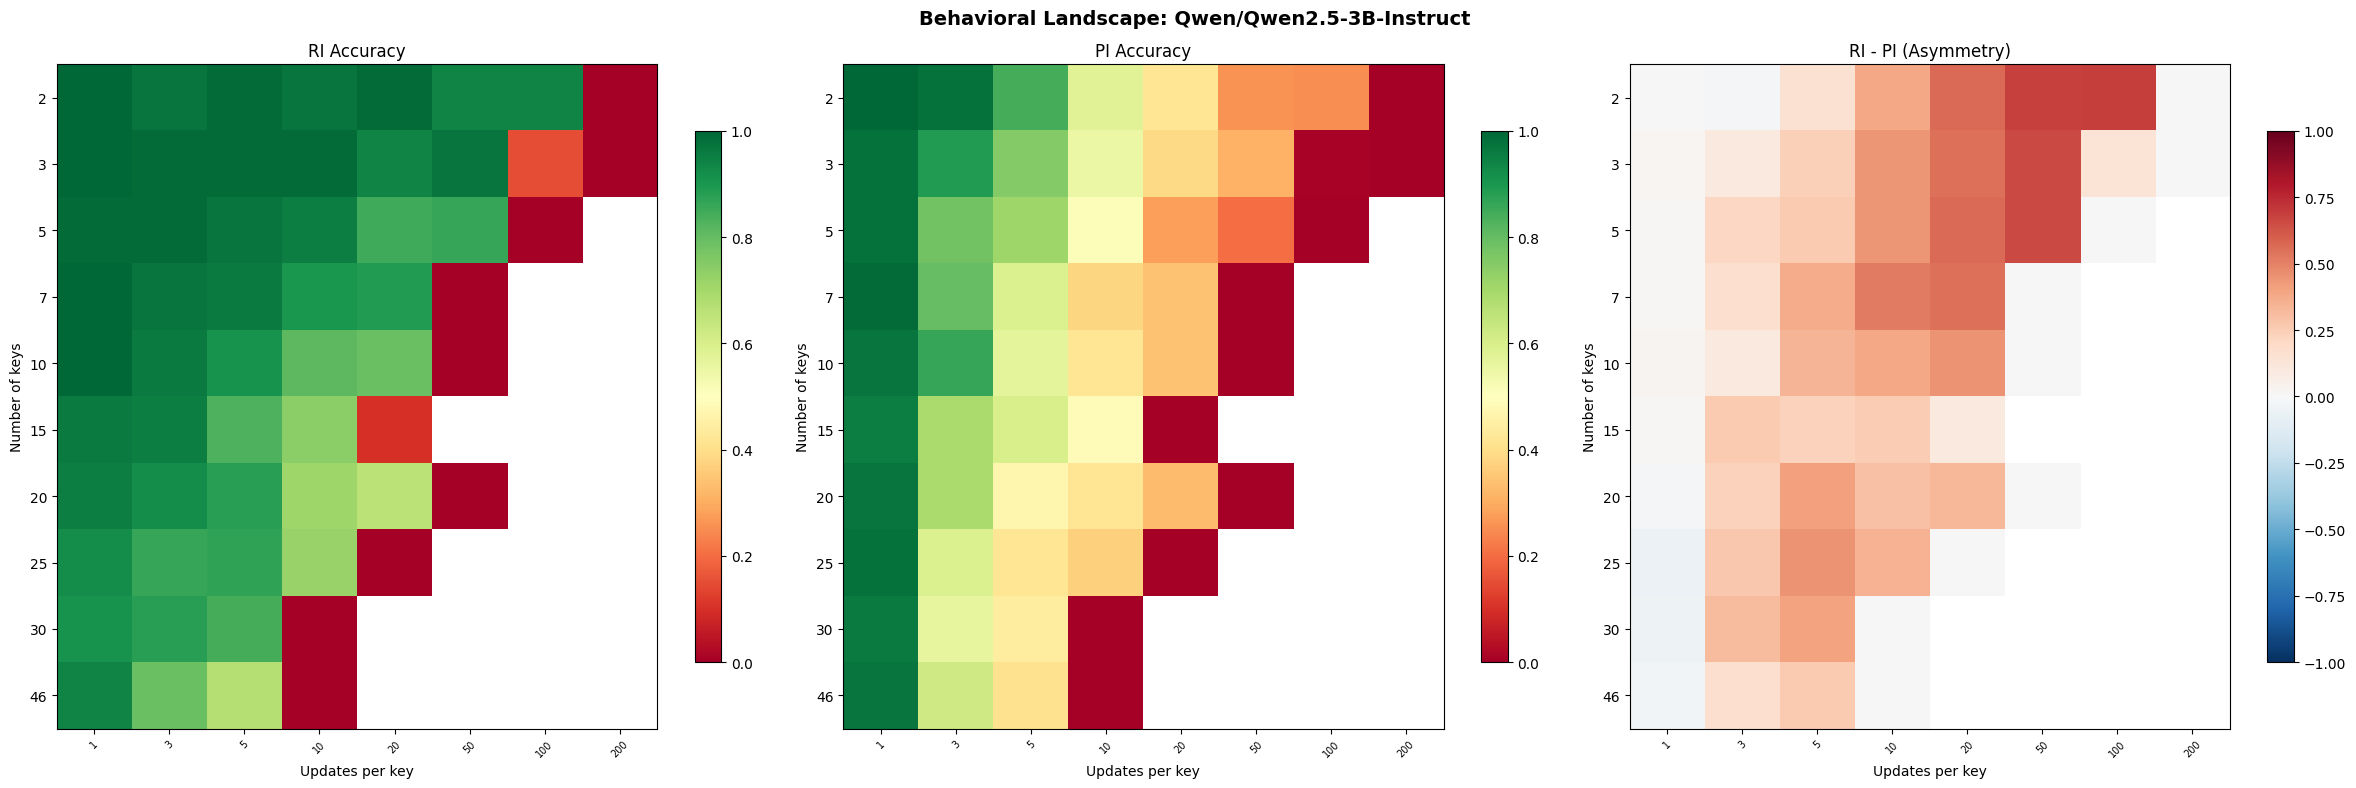

Saved heatmap to /content/figures


In [14]:
# ═══════════════════════════════════════════════════════════════════════════
# Visualization: Heatmaps
# ═══════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for ax_idx, (title, data_fn) in enumerate([
    ("RI Accuracy", lambda c: c["stats"]["RI"]["accuracy"]),
    ("PI Accuracy", lambda c: c["stats"]["PI"]["accuracy"]),
    ("RI - PI (Asymmetry)", lambda c: c["stats"]["RI"]["accuracy"] - c["stats"]["PI"]["accuracy"]),
]):
    ax = axes[ax_idx]
    grid = np.full((len(KEY_LEVELS), len(UPDATE_LEVELS)), np.nan)
    for i, nk in enumerate(KEY_LEVELS):
        for j, nu in enumerate(UPDATE_LEVELS):
            cell_key = f"{nk}_{nu}"
            if cell_key in results["cells"]:
                grid[i, j] = data_fn(results["cells"][cell_key])
    
    if "Asymmetry" in title:
        cmap = "RdBu_r"
        vmin, vmax = -1, 1
    else:
        cmap = "RdYlGn"
        vmin, vmax = 0, 1
    
    im = ax.imshow(grid, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(UPDATE_LEVELS)))
    ax.set_xticklabels(UPDATE_LEVELS, rotation=45, fontsize=7)
    ax.set_yticks(range(len(KEY_LEVELS)))
    ax.set_yticklabels(KEY_LEVELS)
    ax.set_xlabel("Updates per key")
    ax.set_ylabel("Number of keys")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle(f"Behavioral Landscape: {MODEL_NAME}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/behavioral_landscape_{MODEL_NAME.split('/')[-1]}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved heatmap to {FIGURES_DIR}")

In [15]:
# ═══════════════════════════════════════════════════════════════════════════
# Copy results to notebook output (for VSCode-connected Colab)
# ═══════════════════════════════════════════════════════════════════════════
import glob

print("=== Files saved ===")
for f in sorted(glob.glob(f"{SAVE_DIR}/*.json") + glob.glob(f"{FIGURES_DIR}/*.png")):
    size = os.path.getsize(f)
    print(f"  {f} ({size:,} bytes)")

# Print summary JSON (small file) so it appears in notebook output
# VSCode will sync the notebook with this output to your local machine
model_short = MODEL_NAME.split("/")[-1]
summary_path = f"{SAVE_DIR}/behavioral_sweep_{model_short}.json"
if os.path.exists(summary_path):
    print(f"\n=== Summary (copy this if needed) ===")
    with open(summary_path) as f:
        print(f.read())

=== Files saved ===
  /content/figures/behavioral_landscape_Qwen2.5-3B-Instruct.png (92,644 bytes)
  /content/results/behavioral_sweep_Qwen2.5-3B-Instruct_100.json (39,880 bytes)
  /content/results/behavioral_sweep_Qwen2.5-3B-Instruct_100_full.json (4,889,350 bytes)
  /content/results/behavioral_sweep_Qwen2.5-3B-Instruct_100_full_partial.json (4,640,446 bytes)
  /content/results/behavioral_sweep_Qwen2.5-3B-Instruct_100_partial.json (37,832 bytes)
  /content/results/behavioral_sweep_Qwen2.5-3B-Instruct_full_partial.json (1,249,627 bytes)
  /content/results/behavioral_sweep_Qwen2.5-3B-Instruct_partial.json (33,481 bytes)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Visualization: Decay Curves
# ═══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharex=False, sharey=True)
axes = axes.flatten()

for idx, nk in enumerate(KEY_LEVELS):
    ax = axes[idx]
    ri_accs, ri_lo, ri_hi = [], [], []
    pi_accs, pi_lo, pi_hi = [], [], []
    valid_updates = []
    
    for nu in UPDATE_LEVELS:
        cell_key = f"{nk}_{nu}"
        if cell_key in results["cells"]:
            c = results["cells"][cell_key]
            valid_updates.append(nu)
            ri_accs.append(c["stats"]["RI"]["accuracy"])
            ri_lo.append(c["stats"]["RI"]["ci_lower"])
            ri_hi.append(c["stats"]["RI"]["ci_upper"])
            pi_accs.append(c["stats"]["PI"]["accuracy"])
            pi_lo.append(c["stats"]["PI"]["ci_lower"])
            pi_hi.append(c["stats"]["PI"]["ci_upper"])
    
    if valid_updates:
        ax.plot(valid_updates, ri_accs, 'b-o', markersize=3, label='RI', linewidth=1.5)
        ax.fill_between(valid_updates, ri_lo, ri_hi, alpha=0.2, color='blue')
        ax.plot(valid_updates, pi_accs, 'r-s', markersize=3, label='PI', linewidth=1.5)
        ax.fill_between(valid_updates, pi_lo, pi_hi, alpha=0.2, color='red')
    
    ax.set_title(f"Keys={nk}", fontsize=10)
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    ax.set_xscale('log')
    if idx >= 8:
        ax.set_xlabel("Updates")
    if idx % 4 == 0:
        ax.set_ylabel("Accuracy")
    if idx == 0:
        ax.legend(fontsize=8)

plt.suptitle(f"RI vs PI Decay Curves: {MODEL_NAME}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/decay_curves_{MODEL_NAME.split('/')[-1]}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved decay curves to {FIGURES_DIR}")

---

# Local Analysis — Load Pre-computed Results

**Skip all cells above.** Run from here to load a sweep JSON and generate summaries + figures locally (no GPU needed).

In [12]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

# ── Configure paths ──────────────────────────────────────────────────────
# Point this to the directory containing your sweep JSON files.
# Default assumes notebook is in mechanistic_probing_v2/notebooks/
PROJECT_DIR = Path('.').resolve().parent  # mechanistic_probing_v2/
RESULTS_DIR = PROJECT_DIR / 'results'
LOCAL_FIGURES_DIR = PROJECT_DIR / 'figures'
LOCAL_FIGURES_DIR.mkdir(exist_ok=True)

# ── Pick the sweep file to analyze ──────────────────────────────────────
# Change this path when analyzing a different model's sweep
DATA_PATH = RESULTS_DIR / 'qwe0.5b_behavorial_sweep' / 'behavioral_sweep_Qwen2.5-0.5B-Instruct_full.json'

with open(DATA_PATH) as f:
    results = json.load(f)

MODEL_NAME = results['model']
KEY_LEVELS = results['config']['key_levels']
UPDATE_LEVELS = results['config']['update_levels']
TRIALS_PER_CELL = results['config']['trials_per_cell']

print(f'Model: {MODEL_NAME}')
print(f'Cells loaded: {len(results["cells"])}')
print(f'Grid: {len(KEY_LEVELS)} key levels x {len(UPDATE_LEVELS)} update levels')
print(f'Trials per cell: {TRIALS_PER_CELL}')
print(f'Sweep time: {results.get("start_time", "N/A")} -> {results.get("end_time", "N/A")}')
print(f'Figures will be saved to: {LOCAL_FIGURES_DIR}')

Model: Qwen/Qwen2.5-0.5B-Instruct
Cells loaded: 135
Grid: 12 key levels x 17 update levels
Trials per cell: 30
Sweep time: 2026-02-19 19:56:49 -> 2026-02-19 23:01:44
Figures will be saved to: /Users/kanak.raj/workspace/hobby/research_work_ri/mechanistic_probing_v2/figures


In [13]:
# ═══════════════════════════════════════════════════════════════════════════
# Results Summary Statistics
# ═══════════════════════════════════════════════════════════════════════════

def bootstrap_ci(data, n_bootstrap=2000, ci=0.95):
    if not data:
        return 0.0, 0.0, 0.0
    arr = np.array(data, dtype=float)
    mean = arr.mean()
    if len(arr) < 3:
        return mean, 0.0, 1.0
    rng = np.random.RandomState(42)
    boot_means = [rng.choice(arr, size=len(arr), replace=True).mean() for _ in range(n_bootstrap)]
    alpha = (1 - ci) / 2
    return mean, np.percentile(boot_means, alpha * 100), np.percentile(boot_means, (1 - alpha) * 100)

print(f"{'='*70}")
print(f'BEHAVIORAL SWEEP SUMMARY: {MODEL_NAME}')
print(f"{'='*70}")
print(f'Cells completed: {len(results["cells"])}')
print(f'Total trials: {len(results["cells"]) * TRIALS_PER_CELL * 2:,}')
print()

# Regime distribution
regimes = {}
for cell_key, cell_data in results['cells'].items():
    r = cell_data['regime']
    regimes[r] = regimes.get(r, 0) + 1

regime_names = {
    'A': 'Both high (RI>=50%, PI>=50%)',
    'B': 'PI fails first (RI>=50%, PI<50%)',
    'C': 'Both low (RI<50%, PI<50%)',
    'D': 'Unexpected (PI>RI)',
}
print('Regime distribution:')
for r in ['A', 'B', 'C', 'D']:
    count = regimes.get(r, 0)
    pct = count / len(results['cells']) * 100
    print(f'  {r}: {count:>3} cells ({pct:>5.1f}%) — {regime_names[r]}')

# Overall RI vs PI
all_ri = [c['stats']['RI']['accuracy'] for c in results['cells'].values()]
all_pi = [c['stats']['PI']['accuracy'] for c in results['cells'].values()]
print(f'\nOverall accuracy (mean across cells):')
print(f'  RI: {np.mean(all_ri):.3f} (std={np.std(all_ri):.3f})')
print(f'  PI: {np.mean(all_pi):.3f} (std={np.std(all_pi):.3f})')
print(f'  RI - PI: {np.mean(all_ri) - np.mean(all_pi):.3f}')

# Per key-level summary
print(f"\n{'Keys':>6} | {'RI mean':>8} | {'PI mean':>8} | {'Gap':>8} | {'Cells':>5}")
print(f"{'-'*6}-+-{'-'*8}-+-{'-'*8}-+-{'-'*8}-+-{'-'*5}")
for nk in KEY_LEVELS:
    ri_vals = [c['stats']['RI']['accuracy'] for k, c in results['cells'].items() if c['num_keys'] == nk]
    pi_vals = [c['stats']['PI']['accuracy'] for k, c in results['cells'].items() if c['num_keys'] == nk]
    if ri_vals:
        print(f'{nk:>6} | {np.mean(ri_vals):>8.3f} | {np.mean(pi_vals):>8.3f} | {np.mean(ri_vals)-np.mean(pi_vals):>8.3f} | {len(ri_vals):>5}')

# Error type breakdown
print(f'\nError type breakdown (across all trials):')
for cond in ['RI', 'PI']:
    error_totals = {}
    total_trials = 0
    for cell_data in results['cells'].values():
        for etype, count in cell_data['stats'][cond].get('error_types', {}).items():
            error_totals[etype] = error_totals.get(etype, 0) + count
            total_trials += count
    print(f'  {cond}:')
    for etype in sorted(error_totals.keys(), key=lambda x: -error_totals[x]):
        pct = error_totals[etype] / (total_trials if total_trials else 1) * 100
        print(f'    {etype:>25}: {error_totals[etype]:>5} ({pct:>5.1f}%)')

BEHAVIORAL SWEEP SUMMARY: Qwen/Qwen2.5-0.5B-Instruct
Cells completed: 135
Total trials: 8,100

Regime distribution:
  A:  17 cells ( 12.6%) — Both high (RI>=50%, PI>=50%)
  B:  87 cells ( 64.4%) — PI fails first (RI>=50%, PI<50%)
  C:  31 cells ( 23.0%) — Both low (RI<50%, PI<50%)
  D:   0 cells (  0.0%) — Unexpected (PI>RI)

Overall accuracy (mean across cells):
  RI: 0.584 (std=0.254)
  PI: 0.150 (std=0.258)
  RI - PI: 0.434

  Keys |  RI mean |  PI mean |      Gap | Cells
-------+----------+----------+----------+------
     2 |    0.731 |    0.198 |    0.533 |    15
     3 |    0.647 |    0.184 |    0.463 |    17
     5 |    0.567 |    0.155 |    0.412 |    17
     7 |    0.693 |    0.211 |    0.481 |     9
    10 |    0.480 |    0.120 |    0.360 |    15
    15 |    0.671 |    0.175 |    0.496 |     8
    20 |    0.570 |    0.123 |    0.447 |    10
    25 |    0.491 |    0.106 |    0.385 |    11
    30 |    0.533 |    0.126 |    0.407 |     9
    35 |    0.467 |    0.103 |    0.363 

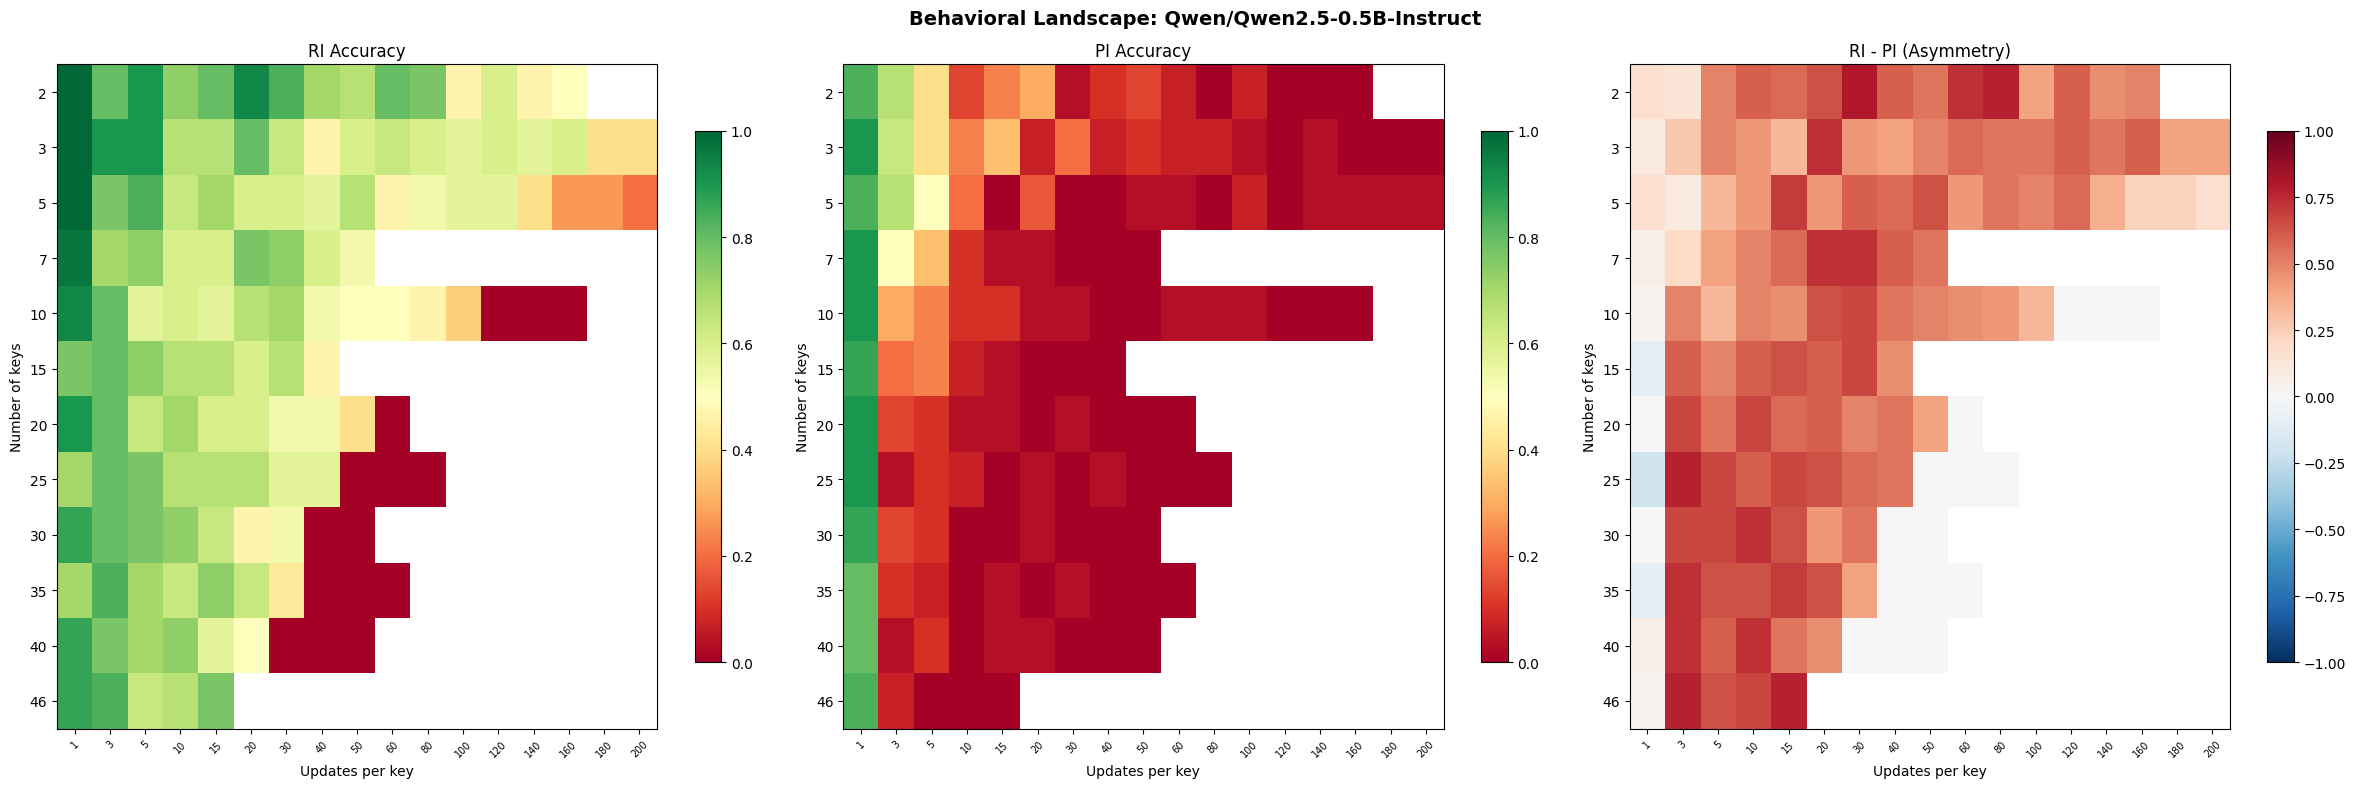

Saved heatmap to /Users/kanak.raj/workspace/hobby/research_work_ri/mechanistic_probing_v2/figures/behavioral_landscape_Qwen2.5-0.5B-Instruct.png


In [14]:
# ═══════════════════════════════════════════════════════════════════════════
# Heatmaps: RI, PI, Asymmetry
# ═══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for ax_idx, (title, data_fn) in enumerate([
    ('RI Accuracy', lambda c: c['stats']['RI']['accuracy']),
    ('PI Accuracy', lambda c: c['stats']['PI']['accuracy']),
    ('RI - PI (Asymmetry)', lambda c: c['stats']['RI']['accuracy'] - c['stats']['PI']['accuracy']),
]):
    ax = axes[ax_idx]
    grid = np.full((len(KEY_LEVELS), len(UPDATE_LEVELS)), np.nan)
    for i, nk in enumerate(KEY_LEVELS):
        for j, nu in enumerate(UPDATE_LEVELS):
            cell_key = f'{nk}_{nu}'
            if cell_key in results['cells']:
                grid[i, j] = data_fn(results['cells'][cell_key])
    
    if 'Asymmetry' in title:
        cmap = 'RdBu_r'
        vmin, vmax = -1, 1
    else:
        cmap = 'RdYlGn'
        vmin, vmax = 0, 1
    
    im = ax.imshow(grid, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(UPDATE_LEVELS)))
    ax.set_xticklabels(UPDATE_LEVELS, rotation=45, fontsize=7)
    ax.set_yticks(range(len(KEY_LEVELS)))
    ax.set_yticklabels(KEY_LEVELS)
    ax.set_xlabel('Updates per key')
    ax.set_ylabel('Number of keys')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.8)

model_short = MODEL_NAME.split('/')[-1]
plt.suptitle(f'Behavioral Landscape: {MODEL_NAME}', fontsize=14, fontweight='bold')
plt.tight_layout()
fig_path = LOCAL_FIGURES_DIR / f'behavioral_landscape_{model_short}.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved heatmap to {fig_path}')

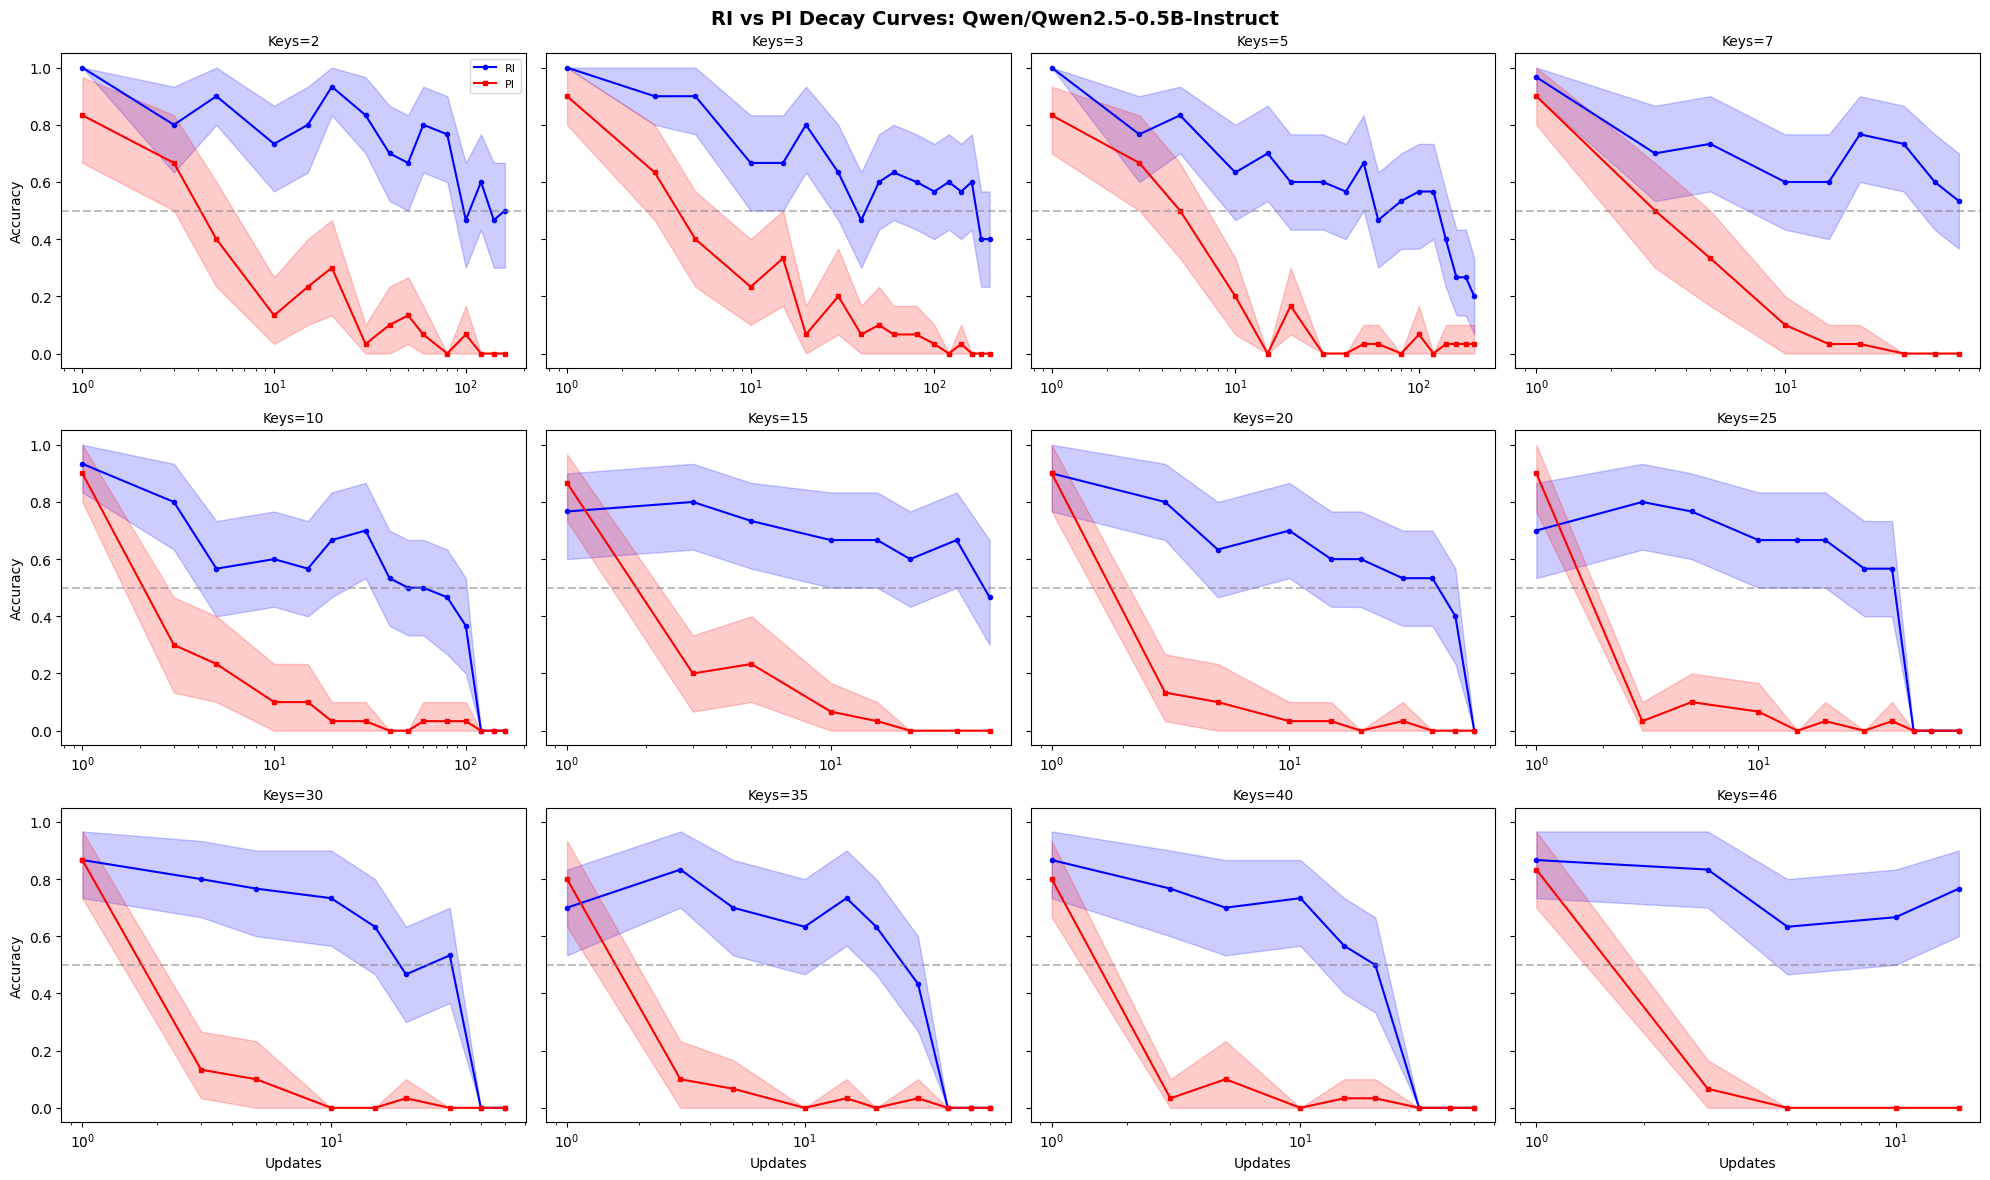

Saved decay curves to /Users/kanak.raj/workspace/hobby/research_work_ri/mechanistic_probing_v2/figures/decay_curves_Qwen2.5-0.5B-Instruct.png


In [15]:
# ═══════════════════════════════════════════════════════════════════════════
# Decay Curves: RI vs PI per key level
# ═══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharex=False, sharey=True)
axes = axes.flatten()

for idx, nk in enumerate(KEY_LEVELS):
    ax = axes[idx]
    ri_accs, ri_lo, ri_hi = [], [], []
    pi_accs, pi_lo, pi_hi = [], [], []
    valid_updates = []
    
    for nu in UPDATE_LEVELS:
        cell_key = f'{nk}_{nu}'
        if cell_key in results['cells']:
            c = results['cells'][cell_key]
            valid_updates.append(nu)
            ri_accs.append(c['stats']['RI']['accuracy'])
            ri_lo.append(c['stats']['RI']['ci_lower'])
            ri_hi.append(c['stats']['RI']['ci_upper'])
            pi_accs.append(c['stats']['PI']['accuracy'])
            pi_lo.append(c['stats']['PI']['ci_lower'])
            pi_hi.append(c['stats']['PI']['ci_upper'])
    
    if valid_updates:
        ax.plot(valid_updates, ri_accs, 'b-o', markersize=3, label='RI', linewidth=1.5)
        ax.fill_between(valid_updates, ri_lo, ri_hi, alpha=0.2, color='blue')
        ax.plot(valid_updates, pi_accs, 'r-s', markersize=3, label='PI', linewidth=1.5)
        ax.fill_between(valid_updates, pi_lo, pi_hi, alpha=0.2, color='red')
    
    ax.set_title(f'Keys={nk}', fontsize=10)
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    ax.set_xscale('log')
    if idx >= 8:
        ax.set_xlabel('Updates')
    if idx % 4 == 0:
        ax.set_ylabel('Accuracy')
    if idx == 0:
        ax.legend(fontsize=8)

model_short = MODEL_NAME.split('/')[-1]
plt.suptitle(f'RI vs PI Decay Curves: {MODEL_NAME}', fontsize=14, fontweight='bold')
plt.tight_layout()
fig_path = LOCAL_FIGURES_DIR / f'decay_curves_{model_short}.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved decay curves to {fig_path}')

In [16]:
# ═══════════════════════════════════════════════════════════════════════════
# Save summary JSON + key paper numbers
# ═══════════════════════════════════════════════════════════════════════════

model_short = MODEL_NAME.split('/')[-1]
summary = {k: v for k, v in results.items() if k != 'cells'}
summary['cells'] = {}
for cell_key, cell_data in results['cells'].items():
    summary['cells'][cell_key] = {k: v for k, v in cell_data.items() if k != 'trials'}

summary_path = RESULTS_DIR / f'behavioral_sweep_{model_short}_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f'Summary saved to {summary_path} ({os.path.getsize(summary_path):,} bytes)')

print(f"\n{'='*50}")
print('KEY NUMBERS FOR PAPER:')
print(f"{'='*50}")

# Count regime B cells (the signature: RI holds, PI fails)
regime_b = sum(1 for c in results['cells'].values() if c['regime'] == 'B')
regime_d = sum(1 for c in results['cells'].values() if c['regime'] == 'D')
print(f'Regime B (PI fails first): {regime_b}/{len(results["cells"])} = {regime_b/len(results["cells"]):.1%}')
print(f'Regime D (PI > RI, unexpected): {regime_d}/{len(results["cells"])} = {regime_d/len(results["cells"]):.1%}')

# Find the boundary: at what updates does PI drop below 50% for each key level?
print(f'\nPI collapse boundary (updates where PI < 50%):')
for nk in KEY_LEVELS:
    for nu in UPDATE_LEVELS:
        cell_key = f'{nk}_{nu}'
        if cell_key in results['cells']:
            pi_acc = results['cells'][cell_key]['stats']['PI']['accuracy']
            ri_acc = results['cells'][cell_key]['stats']['RI']['accuracy']
            if pi_acc < 0.5:
                print(f'  Keys={nk:>3}: PI collapses at {nu} updates (PI={pi_acc:.0%}, RI={ri_acc:.0%})')
                break
    else:
        print(f'  Keys={nk:>3}: PI never collapses (stays >= 50%)')

Summary saved to /Users/kanak.raj/workspace/hobby/research_work_ri/mechanistic_probing_v2/results/behavioral_sweep_Qwen2.5-0.5B-Instruct_summary.json (97,091 bytes)

KEY NUMBERS FOR PAPER:
Regime B (PI fails first): 87/135 = 64.4%
Regime D (PI > RI, unexpected): 0/135 = 0.0%

PI collapse boundary (updates where PI < 50%):
  Keys=  2: PI collapses at 5 updates (PI=40%, RI=90%)
  Keys=  3: PI collapses at 5 updates (PI=40%, RI=90%)
  Keys=  5: PI collapses at 10 updates (PI=20%, RI=63%)
  Keys=  7: PI collapses at 5 updates (PI=33%, RI=73%)
  Keys= 10: PI collapses at 3 updates (PI=30%, RI=80%)
  Keys= 15: PI collapses at 3 updates (PI=20%, RI=80%)
  Keys= 20: PI collapses at 3 updates (PI=13%, RI=80%)
  Keys= 25: PI collapses at 3 updates (PI=3%, RI=80%)
  Keys= 30: PI collapses at 3 updates (PI=13%, RI=80%)
  Keys= 35: PI collapses at 3 updates (PI=10%, RI=83%)
  Keys= 40: PI collapses at 3 updates (PI=3%, RI=77%)
  Keys= 46: PI collapses at 3 updates (PI=7%, RI=83%)
